In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [ ]:

df = pd.read_csv("student_attendance_raw_100k.csv")

print("First 10 rows:")
print(df.head(10))

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

First 10 rows:
   ID StudentName  Attendance            Date-Time
0   1  Ayesha Ali        True  2025-11-03 08:45:00
1   1  Ayesha Ali        True  2025-11-04 08:59:00
2   1  Ayesha Ali       False  2025-11-05 09:00:00
3   1  Ayesha Ali        True  2025-11-06 07:11:00
4   1  Ayesha Ali       False  2025-11-07 09:00:00
5   1  Ayesha Ali        True  2025-11-10 09:46:00
6   1  Ayesha Ali       False  2025-11-11 09:00:00
7   1  Ayesha Ali        True  2025-11-12 08:40:00
8   1  Ayesha Ali       False  2025-11-13 09:00:00
9   1  Ayesha Ali        True  2025-11-14 09:16:00

Dataset Shape:
(2200000, 4)

Columns:
Index(['ID', 'StudentName', 'Attendance', 'Date-Time'], dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2200000 entries, 0 to 2199999
Data columns (total 4 columns):
 #   Column       Dtype
---  ------       -----
 0   ID           int64
 1   StudentName  str  
 2   Attendance   bool 
 3   Date-Time    str  
dtypes: bool(1), int64(1), str(2)
memory usage: 52.5 MB


In [3]:
print("\nTotal Records:")
print(len(df))

print("\nTotal Students:")
print(df["ID"].nunique())

print("\nAttendance Counts:")
print(df["Attendance"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())


Total Records:
2200000

Total Students:
100000

Attendance Counts:
Attendance
True     1338787
False     861213
Name: count, dtype: int64

Missing Values:
ID             0
StudentName    0
Attendance     0
Date-Time      0
dtype: int64


In [ ]:

# DATA PREPROCESSING


df["Date-Time"] = pd.to_datetime(df["Date-Time"])

if df["Attendance"].dtype == "object":

    df["Attendance"] = (
        df["Attendance"].astype(str).str.lower()
        .map({
            "true": 1,
            "false": 0
        })
    )

else:

    df["Attendance"] = df["Attendance"].astype(int)


df = df.sort_values(
    by=["ID", "Date-Time"]
).reset_index(drop=True)


print("\nAfter preprocessing:")

print(df.head(10))

print("\nAttendance values:")
print(df["Attendance"].value_counts())


After preprocessing:
   ID StudentName  Attendance           Date-Time
0   1  Ayesha Ali           1 2025-11-03 08:45:00
1   1  Ayesha Ali           1 2025-11-04 08:59:00
2   1  Ayesha Ali           0 2025-11-05 09:00:00
3   1  Ayesha Ali           1 2025-11-06 07:11:00
4   1  Ayesha Ali           0 2025-11-07 09:00:00
5   1  Ayesha Ali           1 2025-11-10 09:46:00
6   1  Ayesha Ali           0 2025-11-11 09:00:00
7   1  Ayesha Ali           1 2025-11-12 08:40:00
8   1  Ayesha Ali           0 2025-11-13 09:00:00
9   1  Ayesha Ali           1 2025-11-14 09:16:00

Attendance values:
Attendance
1    1338787
0     861213
Name: count, dtype: int64


In [5]:
records_per_student = df.groupby("ID").size()

print("\nRecords per student:")
print(records_per_student.value_counts())


Records per student:
22    100000
Name: count, dtype: int64


In [ ]:
# FEATURE ENGINEERING FUNCTION

def create_student_features(student):

    student = student.sort_values("Date-Time")

    attendance = student["Attendance"].to_numpy()

    first5 = attendance[:5]

    first5_attendance = first5.mean() * 100


    first10 = attendance[:10]

    first10_attendance = first10.mean() * 100


    first15 = attendance[:15]

    first15_attendance = first15.mean() * 100


    change_5_to_10 = (
        first10_attendance -
        first5_attendance
    )



    change_10_to_15 = (
        first15_attendance -
        first10_attendance
    )


    present15 = first15.sum()

    absent15 = 15 - present15


    consecutive_absences = 0

    for value in reversed(first15):
        if value == 0:
            consecutive_absences += 1
        else:
            break



    # ATTENDANCE TREND

    if change_10_to_15 >= 5:

        trend = "Improving"

    elif change_10_to_15 <= -5:

        trend = "Declining"

    else:

        trend = "Stable"



    final_attendance = attendance[:22].mean() * 100

    target = int(
        final_attendance >= 68
    )

    return pd.Series({

        "StudentName":
            student["StudentName"].iloc[0],

        "First5Attendance":
            first5_attendance,

        "First10Attendance":
            first10_attendance,

        "First15Attendance":
            first15_attendance,

        "Change5to10":
            change_5_to_10,

        "Change10to15":
            change_10_to_15,

        "Present15":
            present15,

        "Absent15":
            absent15,

        "ConsecutiveAbsences":
            consecutive_absences,

        "AttendanceTrend":
            trend,

        "FinalAttendance":
            final_attendance,

        "Target":
            target
    })

In [47]:

student_data = (
    df.groupby("ID")
    .apply(create_student_features)
    .reset_index()
)


print("\nStudent Level Dataset:")

print(student_data.head(20))


print("\nShape:")
print(student_data.shape)


Student Level Dataset:
    ID      StudentName  First5Attendance  First10Attendance  \
0    1       Ayesha Ali              60.0               60.0   
1    2    Umar Chaudhry              40.0               50.0   
2    3  Abdullah Sheikh              80.0               90.0   
3    4        Hamza Ali              40.0               40.0   
4    5     Fatima Aslam             100.0               90.0   
5    6    Ahmed Qureshi              40.0               60.0   
6    7     Huzaifa Khan              80.0               80.0   
7    8       Umar Ahmed              40.0               30.0   
8    9     Bilal Sheikh              40.0               40.0   
9   10     Ibrahim Shah             100.0               80.0   
10  11       Umar Aslam             100.0               60.0   
11  12      Bilal Aslam              80.0               70.0   
12  13   Huzaifa Sheikh              80.0               70.0   
13  14    Fahad Qureshi              40.0               50.0   
14  15       Ahs

In [9]:
print("\nStudent Features:")
print(student_data.columns)


print("\nTarget Distribution:")
print(student_data["Target"].value_counts())


print("\nTarget Percentage:")
print(
    student_data["Target"]
    .value_counts(normalize=True)
    * 100
)


Student Features:
Index(['ID', 'StudentName', 'First5Attendance', 'First10Attendance',
       'First15Attendance', 'Change5to10', 'Change10to15', 'Present15',
       'Absent15', 'ConsecutiveAbsences', 'AttendanceTrend', 'FinalAttendance',
       'Target'],
      dtype='str')

Target Distribution:
Target
0    55601
1    44399
Name: count, dtype: int64

Target Percentage:
Target
0    55.601
1    44.399
Name: proportion, dtype: float64


In [10]:
print(
    student_data[
        [
            "ID",
            "StudentName",
            "First5Attendance",
            "First10Attendance",
            "First15Attendance",
            "AttendanceTrend",
            "FinalAttendance",
            "Target"
        ]
    ].head(20)
)

    ID      StudentName  First5Attendance  First10Attendance  \
0    1       Ayesha Ali              60.0               60.0   
1    2    Umar Chaudhry              40.0               50.0   
2    3  Abdullah Sheikh              80.0               90.0   
3    4        Hamza Ali              40.0               40.0   
4    5     Fatima Aslam             100.0               90.0   
5    6    Ahmed Qureshi              40.0               60.0   
6    7     Huzaifa Khan              80.0               80.0   
7    8       Umar Ahmed              40.0               30.0   
8    9     Bilal Sheikh              40.0               40.0   
9   10     Ibrahim Shah             100.0               80.0   
10  11       Umar Aslam             100.0               60.0   
11  12      Bilal Aslam              80.0               70.0   
12  13   Huzaifa Sheikh              80.0               70.0   
13  14    Fahad Qureshi              40.0               50.0   
14  15       Ahsan Alam             100.

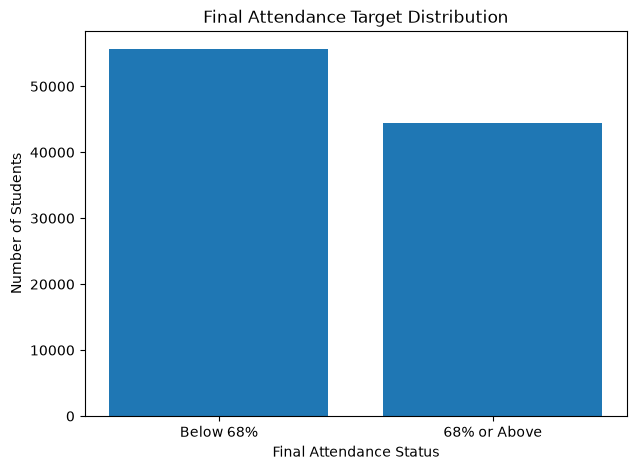

In [ ]:
target_counts = student_data["Target"].value_counts()


plt.figure(figsize=(7, 5))

plt.bar(

    ["Below 68%", "68% or Above"],

    [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
)

plt.title(
    "Final Attendance Target Distribution"
)

plt.xlabel(
    "Final Attendance Status"
)

plt.ylabel(
    "Number of Students"
)

plt.show()

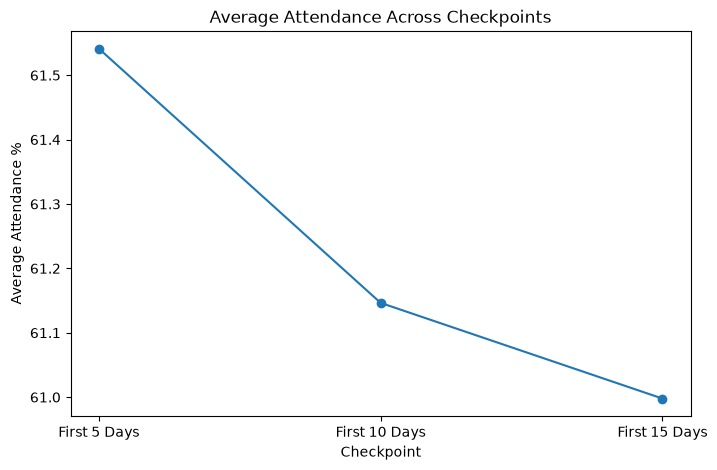

In [11]:
checkpoint_average = [

    student_data[
        "First5Attendance"
    ].mean(),

    student_data[
        "First10Attendance"
    ].mean(),

    student_data[
        "First15Attendance"
    ].mean()

]


plt.figure(figsize=(8, 5))


plt.plot(

    [
        "First 5 Days",
        "First 10 Days",
        "First 15 Days"
    ],

    checkpoint_average,

    marker="o"

)


plt.title(
    "Average Attendance Across Checkpoints"
)

plt.xlabel(
    "Checkpoint"
)

plt.ylabel(
    "Average Attendance %"
)

plt.show()

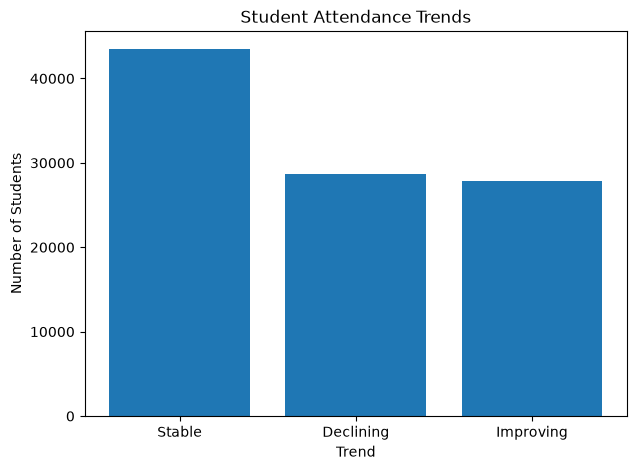

In [12]:
trend_counts = (
    student_data[
        "AttendanceTrend"
    ]
    .value_counts()
)


plt.figure(figsize=(7, 5))


plt.bar(

    trend_counts.index,

    trend_counts.values

)


plt.title(
    "Student Attendance Trends"
)

plt.xlabel(
    "Trend"
)

plt.ylabel(
    "Number of Students"
)

plt.show()

In [ ]:

encoded_data = pd.get_dummies(student_data,columns=["AttendanceTrend"],dtype=int)

print("\nAfter get_dummies:")

print(encoded_data.head())

print("\nColumns:")

print(encoded_data.columns)


After get_dummies:
   ID      StudentName  First5Attendance  First10Attendance  \
0   1       Ayesha Ali              60.0               60.0   
1   2    Umar Chaudhry              40.0               50.0   
2   3  Abdullah Sheikh              80.0               90.0   
3   4        Hamza Ali              40.0               40.0   
4   5     Fatima Aslam             100.0               90.0   

   First15Attendance  Change5to10  Change10to15  Present15  Absent15  \
0          60.000000          0.0      0.000000          9         6   
1          66.666667         10.0     16.666667         10         5   
2          86.666667         10.0     -3.333333         13         2   
3          33.333333          0.0     -6.666667          5        10   
4          86.666667        -10.0     -3.333333         13         2   

   ConsecutiveAbsences  FinalAttendance  Target  AttendanceTrend_Declining  \
0                    1        63.636364       0                          0   
1           

In [16]:
# FEATURES

feature_columns = [

    "First5Attendance",

    "First10Attendance",

    "First15Attendance",

    "Change5to10",

    "Change10to15",

    "ConsecutiveAbsences",

    "AttendanceTrend_Declining",

    "AttendanceTrend_Improving",

    "AttendanceTrend_Stable"
]


X = encoded_data[
    feature_columns
]


# Target
y = encoded_data[
    "Target"
]


print("\nX:")
print(X.head())


print("\nY:")
print(y.head())


print("\nX Shape:")
print(X.shape)


print("\nY Shape:")
print(y.shape)


X:
   First5Attendance  First10Attendance  First15Attendance  Change5to10  \
0              60.0               60.0          60.000000          0.0   
1              40.0               50.0          66.666667         10.0   
2              80.0               90.0          86.666667         10.0   
3              40.0               40.0          33.333333          0.0   
4             100.0               90.0          86.666667        -10.0   

   Change10to15  ConsecutiveAbsences  AttendanceTrend_Declining  \
0      0.000000                    1                          0   
1     16.666667                    0                          0   
2     -3.333333                    1                          0   
3     -6.666667                    0                          1   
4     -3.333333                    0                          0   

   AttendanceTrend_Improving  AttendanceTrend_Stable  
0                          0                       1  
1                          1          

In [17]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


print("\nTraining Features:")
print(X_train.shape)


print("\nTesting Features:")
print(X_test.shape)


print("\nTraining Target:")
print(y_train.shape)


print("\nTesting Target:")
print(y_test.shape)


Training Features:
(80000, 9)

Testing Features:
(20000, 9)

Training Target:
(80000,)

Testing Target:
(20000,)


In [ ]:

# LOGISTIC REGRESSION


model = LogisticRegression(max_iter=3000)

model.fit(X_train,y_train)

print(
    "\nLogistic Regression training completed!"
)


Logistic Regression training completed!


In [19]:
# PREDICTION

y_pred = model.predict(X_test)

print("\nFirst 20 Predictions:")

print(
    y_pred[:20]
)


First 20 Predictions:
[0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1]


In [31]:
# PROBABILITY

y_probability = model.predict_proba(X_test)[:, 1]

print("\nFirst 20 Probabilities:")

print(
    y_probability[:20]
)


First 20 Probabilities:
[1.36263183e-04 2.82297858e-06 3.07139033e-03 2.72214230e-03
 2.05362772e-01 5.42300659e-01 2.42311217e-03 1.99433526e-03
 5.49129060e-02 1.91424029e-01 5.19605827e-06 9.52674465e-01
 9.97668712e-01 6.62498028e-04 5.20031742e-01 4.86364909e-01
 4.07509722e-02 6.22302190e-02 1.03812494e-06 9.90875636e-01]


In [55]:
accuracy = accuracy_score(y_test,y_pred)

print(f"\nAccuracy: {accuracy * 100:.2f}%")


Accuracy: 89.62%


In [33]:
recall = recall_score(y_test,y_pred)

print(
    f"Recall: {recall * 100:.2f}%"
)

Recall: 91.36%


In [34]:
f1 = f1_score(y_test,y_pred)

print(
    f"F1 Score: {f1 * 100:.2f}%"
)

F1 Score: 88.66%


In [35]:
print("\nClassification Report:")

print(

    classification_report(y_test,y_pred,
        target_names=[
            "Below 68%",
            "68% or Above"
        ]
    )
)


Classification Report:
              precision    recall  f1-score   support

   Below 68%       0.93      0.88      0.90     11120
68% or Above       0.86      0.91      0.89      8880

    accuracy                           0.90     20000
   macro avg       0.89      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000




Confusion Matrix:
[[9811 1309]
 [ 767 8113]]


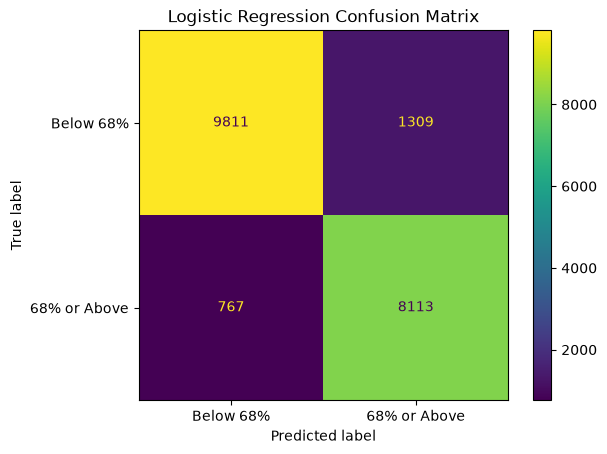

In [36]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test,y_pred)

print("\nConfusion Matrix:")

print(cm)


ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "Below 68%",

        "68% or Above"

    ]

).plot()


plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [37]:
# LOGISTIC REGRESSION COEFFICIENTS


feature_importance = pd.DataFrame({

    "Feature":
        X.columns,

    "Coefficient":
        model.coef_[0]

})


feature_importance[
    "AbsoluteImportance"
] = abs(

    feature_importance[
        "Coefficient"
    ]

)


feature_importance = (

    feature_importance

    .sort_values(

        by="AbsoluteImportance",

        ascending=False

    )

)


print(
    "\nFeature Importance:"
)

print(
    feature_importance
)


Feature Importance:
                     Feature  Coefficient  AbsoluteImportance
6  AttendanceTrend_Declining    -3.792594            3.792594
8     AttendanceTrend_Stable    -3.657120            3.657120
7  AttendanceTrend_Improving    -3.492656            3.492656
2          First15Attendance     0.137284            0.137284
4               Change10to15     0.079674            0.079674
5        ConsecutiveAbsences    -0.074568            0.074568
1          First10Attendance     0.057610            0.057610
3                Change5to10     0.031008            0.031008
0           First5Attendance     0.026602            0.026602


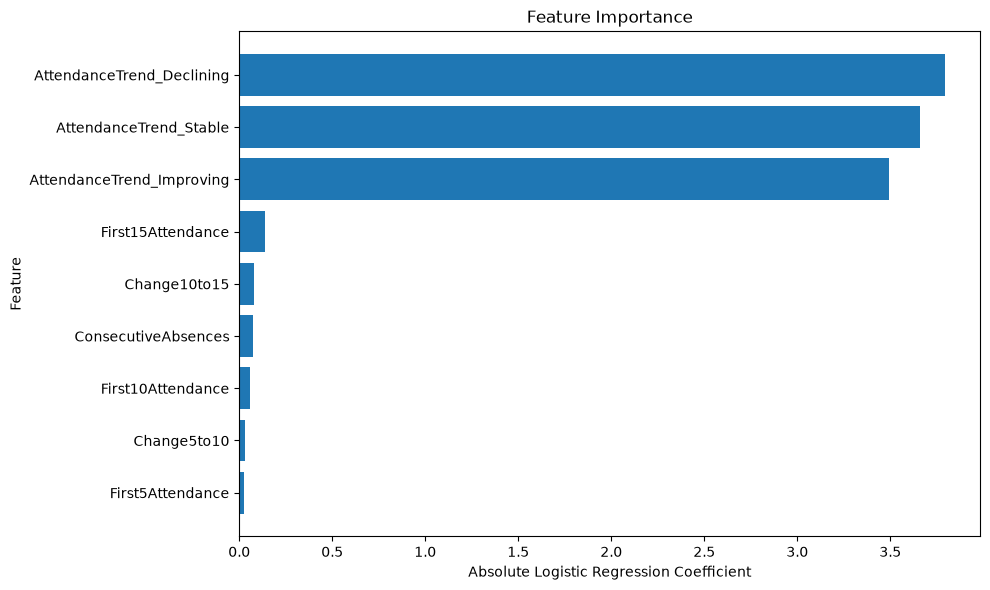

In [38]:
plt.figure(
    figsize=(10, 6)
)


plt.barh(

    feature_importance[
        "Feature"
    ],

    feature_importance[
        "AbsoluteImportance"
    ]

)


plt.xlabel(
    "Absolute Logistic Regression Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Feature Importance"
)


plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [54]:
# ============================================================
# STUDENT PREDICTION RESULTS
# ============================================================

test_results = encoded_data.loc[
    X_test.index,

    [
        "ID",
        "StudentName",
        "First5Attendance",
        "First10Attendance",
        "First15Attendance",
        "Change5to10",
        "Change10to15",
        "FinalAttendance",
        "Target"
    ]

].copy()


test_results[
    "PredictedTarget"
] = y_pred


test_results[
    "Probability"
] = y_probability


print(
    "\nPrediction Results:"
)


print(
    test_results.head(30)
)


Prediction Results:
          ID       StudentName  First5Attendance  First10Attendance  \
38810  38811         Zain Alam              20.0               30.0   
63163  63164      Huzaifa Khan              40.0               20.0   
66508  66509       Fahad Akram              40.0               30.0   
58239  58240        Usman Khan              40.0               50.0   
81067  81068        Bilal Shah              60.0               60.0   
91210  91211         Umar Shah              80.0               60.0   
5373    5374      Shahzaib Ali              60.0               40.0   
8577    8578     Shahzaib Shah              60.0               50.0   
90771  90772      Zainab Aslam              60.0               70.0   
34655  34656    Ahsan Chaudhry              80.0               50.0   
56808  56809        Hamza Khan              20.0               20.0   
4926    4927       Hamza Aslam              80.0               80.0   
56530  56531       Maryam Alam              80.0        

In [40]:
test_results[
    "ActualResult"
] = test_results[
    "Target"
].map({

    0: "Below 68%",

    1: "68% or Above"

})


test_results[
    "PredictedResult"
] = test_results[
    "PredictedTarget"
].map({

    0: "Will NOT Reach 68%",

    1: "Will Reach 68%"

})


# Convert probability into percentage

test_results[
    "ProbabilityPercent"
] = (

    test_results[
        "Probability"
    ] * 100

).round(2)


print(

    test_results[

        [
            "ID",
            "StudentName",
            "First5Attendance",
            "First10Attendance",
            "First15Attendance",
            "PredictedResult",
            "ProbabilityPercent",
            "ActualResult"
        ]

    ].head(30)

)

          ID       StudentName  First5Attendance  First10Attendance  \
38810  38811         Zain Alam              20.0               30.0   
63163  63164      Huzaifa Khan              40.0               20.0   
66508  66509       Fahad Akram              40.0               30.0   
58239  58240        Usman Khan              40.0               50.0   
81067  81068        Bilal Shah              60.0               60.0   
91210  91211         Umar Shah              80.0               60.0   
5373    5374      Shahzaib Ali              60.0               40.0   
8577    8578     Shahzaib Shah              60.0               50.0   
90771  90772      Zainab Aslam              60.0               70.0   
34655  34656    Ahsan Chaudhry              80.0               50.0   
56808  56809        Hamza Khan              20.0               20.0   
4926    4927       Hamza Aslam              80.0               80.0   
56530  56531       Maryam Alam              80.0               90.0   
45902 

In [41]:
student = test_results.iloc[0]


print("\n================================")
print("STUDENT ATTENDANCE ANALYSIS")
print("================================")


print(
    "Student:",
    student["StudentName"]
)


print(
    "ID:",
    student["ID"]
)


print("\nAttendance Progress:")


print(
    f"First 5 Days:  {student['First5Attendance']:.2f}%"
)


print(
    f"First 10 Days: {student['First10Attendance']:.2f}%"
)


print(
    f"First 15 Days: {student['First15Attendance']:.2f}%"
)


print("\nAttendance Changes:")


print(
    f"Day 5 -> 10: {student['Change5to10']:.2f}%"
)


print(
    f"Day 10 -> 15: {student['Change10to15']:.2f}%"
)


print("\nModel Prediction:")


print(
    student["PredictedResult"]
)


print(
    f"Probability: {student['ProbabilityPercent']:.2f}%"
)


print("\nActual Final Attendance:")


print(
    f"{student['FinalAttendance']:.2f}%"
)


print(
    "Actual:",
    student["ActualResult"]
)


STUDENT ATTENDANCE ANALYSIS
Student: Zain Alam
ID: 38811

Attendance Progress:
First 5 Days:  20.00%
First 10 Days: 30.00%
First 15 Days: 26.67%

Attendance Changes:
Day 5 -> 10: 10.00%
Day 10 -> 15: -3.33%

Model Prediction:
Will NOT Reach 68%
Probability: 0.01%

Actual Final Attendance:
18.18%
Actual: Below 68%


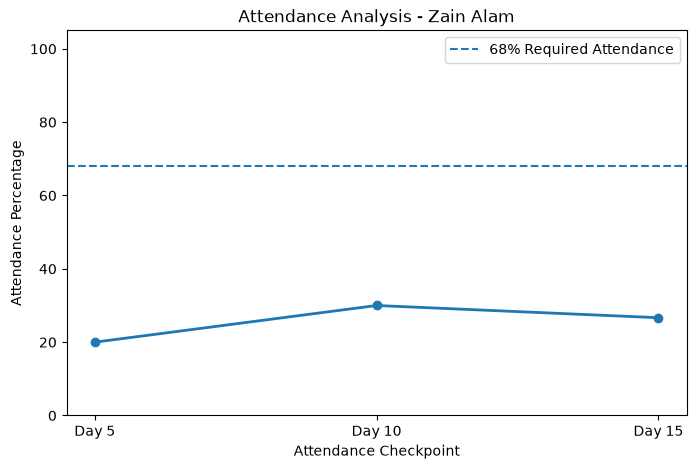

In [42]:
checkpoints = [

    "Day 5",

    "Day 10",

    "Day 15"

]


attendance_values = [

    student[
        "First5Attendance"
    ],

    student[
        "First10Attendance"
    ],

    student[
        "First15Attendance"
    ]

]


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    checkpoints,

    attendance_values,

    marker="o",

    linewidth=2

)


# 68% threshold
plt.axhline(

    y=68,

    linestyle="--",

    label="68% Required Attendance"

)


plt.xlabel(
    "Attendance Checkpoint"
)

plt.ylabel(
    "Attendance Percentage"
)


plt.title(

    f"Attendance Analysis - {student['StudentName']}"

)


plt.ylim(
    0,
    105
)


plt.legend()

plt.show()

In [43]:
test_results[
    "CorrectPrediction"
] = (

    test_results[
        "Target"
    ]

    ==

    test_results[
        "PredictedTarget"
    ]

)


print("\nCorrect Predictions:")

print(

    test_results[
        "CorrectPrediction"
    ].value_counts()

)


Correct Predictions:
CorrectPrediction
True     17924
False     2076
Name: count, dtype: int64


In [44]:
wrong_predictions = test_results[

    test_results[
        "CorrectPrediction"
    ] == False

]


print("\nWrong Predictions:")

print(

    wrong_predictions[

        [
            "StudentName",
            "First5Attendance",
            "First10Attendance",
            "First15Attendance",
            "ProbabilityPercent",
            "PredictedResult",
            "FinalAttendance",
            "ActualResult"
        ]

    ].head(30)

)


Wrong Predictions:
            StudentName  First5Attendance  First10Attendance  \
91210         Umar Shah              80.0               60.0   
9234         Ahmed Butt              80.0               70.0   
28636        Taha Javed              40.0               50.0   
33112         Hira Butt              80.0               80.0   
53242        Saad Aslam              60.0               70.0   
54460      Huzaifa Alam              80.0               70.0   
64458      Maryam Malik              80.0               90.0   
27703         Saad Butt              60.0               70.0   
72054     Ayesha Sheikh              60.0               60.0   
9343         Zain Malik              80.0               80.0   
40774   Muneeb Chaudhry              60.0               80.0   
863         Fahad Javed              80.0               60.0   
65213         Saad Shah              80.0               80.0   
73825        Zainab Ali             100.0               80.0   
30108       Bilal Ah

In [45]:
student_data.to_csv(

    "student_engineered_features.csv",

    index=False

)


print(
    "Feature dataset saved successfully."
)

Feature dataset saved successfully.


In [46]:
test_results.to_csv(

    "student_model_predictions.csv",

    index=False

)


print(
    "Predictions saved successfully."
)

Predictions saved successfully.


In [52]:


# new_student = pd.DataFrame({

#     "First5Attendance": [80],

#     "First10Attendance": [90],

#     "First15Attendance": [86.67],

#     "Change5to10": [10],

#     "Change10to15": [-3.33],

#     "ConsecutiveAbsences": [0],

#     "AttendanceTrend_Declining": [0],

#     "AttendanceTrend_Improving": [0],

#     "AttendanceTrend_Stable": [1]

# })

# new_student = pd.DataFrame({
#     "First5Attendance": [60],
#     "First10Attendance": [70],
#     "First15Attendance": [66.67],
#     "Change5to10": [10],
#     "Change10to15": [-3.33],
#     "ConsecutiveAbsences": [2],
#     "AttendanceTrend_Declining": [0],
#     "AttendanceTrend_Improving": [0],
#     "AttendanceTrend_Stable": [1]
# })

new_student = pd.DataFrame({
    "First5Attendance": [100],
    "First10Attendance": [90],
    "First15Attendance": [66.67],
    "Change5to10": [-10],
    "Change10to15": [-23.33],
    "ConsecutiveAbsences": [5],
    "AttendanceTrend_Declining": [1],
    "AttendanceTrend_Improving": [0],
    "AttendanceTrend_Stable": [0]
})

In [53]:
prediction = model.predict(new_student)

print("Prediction:", prediction)

Prediction: [0]
